In [38]:
import numpy as np
import qutip as qt
import matplotlib.pyplot as plt
from quantumScarFunctions import *
from quantumScarsPlotting import *
import time

In [39]:
N = 8
wd = 0.6366896896896898
wm = 1.0
t_max = 50
tlist = np.linspace(0, t_max, 200)
reals = 100
dis = 0.5
N_dis = 2
amp = 0.5

100 realizations in 6.3 s (0.06349 s per realization)


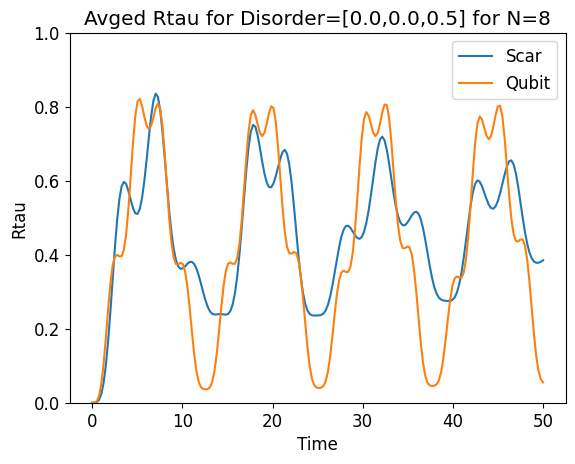

In [40]:
dz = 0.0
dy = 0.0
dx = dis
N_dis = 2

args = {"A": amp, "omega": wd}
qargs = {"A": amp, "omega": wm}

H0_clean, eigenvalues, eigenstates, psi0, basisList = get_scar_ham(N)
H1, driveWeights = get_scar_H1(N, basisList)

t0 = time.perf_counter()
full_scar = 0
for _ in range(reals):
    H0, eigenvalues, eigenstates = get_dis_scar_ham(H0_clean, N, basisList, ham_disorder=[dz, dy, dx], N_dis=N_dis)
    bandwidth = eigenvalues[-1] - eigenvalues[0]

    H = qt.QobjEvo([H0, [H1, coeff]], args=args)
    psi_t = qt.sesolve(H, eigenstates[0], tlist, e_ops=[H0])
    Rtau_scar = np.array(np.real(psi_t.expect[0] - psi_t.expect[0][0]) / bandwidth)
    full_scar += Rtau_scar

xfull_scar = full_scar / reals

full_qubit = 0
for _ in range(reals):
    qH0_list, qH1_list, _ = get_qubit_ham(N, wm=wm, ham_disorder=[dz, dy, dx], N_dis=N_dis)

    dE_tot = 0
    bw_tot = 0
    for qH0, qH1 in zip(qH0_list, qH1_list):
        qeigenvalues, qeigenstates = qH0.eigenstates()
        bw_tot += qeigenvalues[-1] - qeigenvalues[0]

        qH = qt.QobjEvo([qH0, [qH1, coeff]], args=qargs)
        qpsi_t = qt.sesolve(qH, qeigenstates[0], tlist, e_ops=[qH0])
        dE_tot = dE_tot + np.real(qpsi_t.expect[0] - qpsi_t.expect[0][0])

    full_qubit += dE_tot / bw_tot

xfull_qubit = full_qubit / reals
elapsed = time.perf_counter() - t0

print(f"{reals} realizations in {elapsed:.1f} s "
      f"({elapsed/reals:.5f} s per realization)")

plt.title(f"Avged Rtau for Disorder=[{dz},{dy},{dx}] for N={N}")
plt.xlabel("Time")
plt.ylabel("Rtau")
plt.plot(tlist, xfull_scar, label="Scar")
plt.plot(tlist, xfull_qubit, label="Qubit")
plt.legend()
plt.ylim(0, 1)
plt.show()

100 realizations in 6.7 s (0.06689 s per realization)


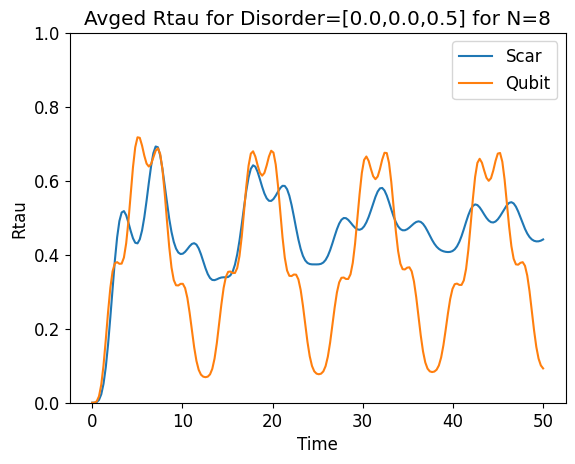

In [41]:
dz = 0.0
dy = 0.0
dx = dis
N_dis = 4

args = {"A": amp, "omega": wd}
qargs = {"A": amp, "omega": wm}

H0_clean, eigenvalues, eigenstates, psi0, basisList = get_scar_ham(N)
H1, driveWeights = get_scar_H1(N, basisList)

t0 = time.perf_counter()
full_scar = 0
for _ in range(reals):
    H0, eigenvalues, eigenstates = get_dis_scar_ham(H0_clean, N, basisList, ham_disorder=[dz, dy, dx], N_dis=N_dis)
    bandwidth = eigenvalues[-1] - eigenvalues[0]

    H = qt.QobjEvo([H0, [H1, coeff]], args=args)
    psi_t = qt.sesolve(H, eigenstates[0], tlist, e_ops=[H0])
    Rtau_scar = np.array(np.real(psi_t.expect[0] - psi_t.expect[0][0]) / bandwidth)
    full_scar += Rtau_scar

xfull_scar = full_scar / reals

full_qubit = 0
for _ in range(reals):
    qH0_list, qH1_list, _ = get_qubit_ham(N, wm=wm, ham_disorder=[dz, dy, dx], N_dis=N_dis)

    dE_tot = 0
    bw_tot = 0
    for qH0, qH1 in zip(qH0_list, qH1_list):
        qeigenvalues, qeigenstates = qH0.eigenstates()
        bw_tot += qeigenvalues[-1] - qeigenvalues[0]

        qH = qt.QobjEvo([qH0, [qH1, coeff]], args=qargs)
        qpsi_t = qt.sesolve(qH, qeigenstates[0], tlist, e_ops=[qH0])
        dE_tot = dE_tot + np.real(qpsi_t.expect[0] - qpsi_t.expect[0][0])

    full_qubit += dE_tot / bw_tot

xfull_qubit = full_qubit / reals
elapsed = time.perf_counter() - t0

print(f"{reals} realizations in {elapsed:.1f} s "
      f"({elapsed/reals:.5f} s per realization)")

plt.title(f"Avged Rtau for Disorder=[{dz},{dy},{dx}] for N={N}")
plt.xlabel("Time")
plt.ylabel("Rtau")
plt.plot(tlist, xfull_scar, label="Scar")
plt.plot(tlist, xfull_qubit, label="Qubit")
plt.legend()
plt.ylim(0, 1)
plt.show()

100 realizations in 6.6 s (0.06592 s per realization)


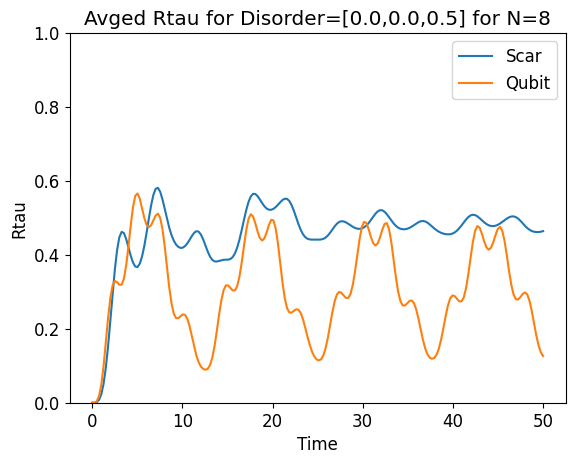

In [42]:
dz = 0.0
dy = 0.0
dx = dis
N_dis = 6

args = {"A": amp, "omega": wd}
qargs = {"A": amp, "omega": wm}

H0_clean, eigenvalues, eigenstates, psi0, basisList = get_scar_ham(N)
H1, driveWeights = get_scar_H1(N, basisList)

t0 = time.perf_counter()
full_scar = 0
for _ in range(reals):
    H0, eigenvalues, eigenstates = get_dis_scar_ham(H0_clean, N, basisList, ham_disorder=[dz, dy, dx], N_dis=N_dis)
    bandwidth = eigenvalues[-1] - eigenvalues[0]

    H = qt.QobjEvo([H0, [H1, coeff]], args=args)
    psi_t = qt.sesolve(H, eigenstates[0], tlist, e_ops=[H0])
    Rtau_scar = np.array(np.real(psi_t.expect[0] - psi_t.expect[0][0]) / bandwidth)
    full_scar += Rtau_scar

xfull_scar = full_scar / reals

full_qubit = 0
for _ in range(reals):
    qH0_list, qH1_list, _ = get_qubit_ham(N, wm=wm, ham_disorder=[dz, dy, dx], N_dis=N_dis)

    dE_tot = 0
    bw_tot = 0
    for qH0, qH1 in zip(qH0_list, qH1_list):
        qeigenvalues, qeigenstates = qH0.eigenstates()
        bw_tot += qeigenvalues[-1] - qeigenvalues[0]

        qH = qt.QobjEvo([qH0, [qH1, coeff]], args=qargs)
        qpsi_t = qt.sesolve(qH, qeigenstates[0], tlist, e_ops=[qH0])
        dE_tot = dE_tot + np.real(qpsi_t.expect[0] - qpsi_t.expect[0][0])

    full_qubit += dE_tot / bw_tot

xfull_qubit = full_qubit / reals
elapsed = time.perf_counter() - t0

print(f"{reals} realizations in {elapsed:.1f} s "
      f"({elapsed/reals:.5f} s per realization)")

plt.title(f"Avged Rtau for Disorder=[{dz},{dy},{dx}] for N={N}")
plt.xlabel("Time")
plt.ylabel("Rtau")
plt.plot(tlist, xfull_scar, label="Scar")
plt.plot(tlist, xfull_qubit, label="Qubit")
plt.legend()
plt.ylim(0, 1)
plt.show()

100 realizations in 6.8 s (0.06799 s per realization)


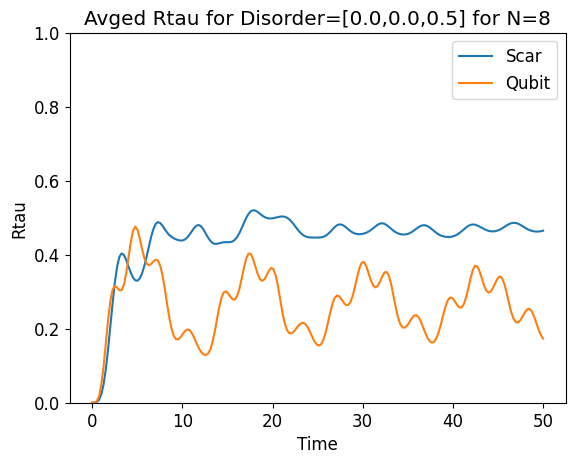

In [43]:
dz = 0.0
dy = 0.0
dx = dis
N_dis = 8

args = {"A": amp, "omega": wd}
qargs = {"A": amp, "omega": wm}

H0_clean, eigenvalues, eigenstates, psi0, basisList = get_scar_ham(N)
H1, driveWeights = get_scar_H1(N, basisList)

t0 = time.perf_counter()
full_scar = 0
for _ in range(reals):
    H0, eigenvalues, eigenstates = get_dis_scar_ham(H0_clean, N, basisList, ham_disorder=[dz, dy, dx], N_dis=N_dis)
    bandwidth = eigenvalues[-1] - eigenvalues[0]

    H = qt.QobjEvo([H0, [H1, coeff]], args=args)
    psi_t = qt.sesolve(H, eigenstates[0], tlist, e_ops=[H0])
    Rtau_scar = np.array(np.real(psi_t.expect[0] - psi_t.expect[0][0]) / bandwidth)
    full_scar += Rtau_scar

xfull_scar = full_scar / reals

full_qubit = 0
for _ in range(reals):
    qH0_list, qH1_list, _ = get_qubit_ham(N, wm=wm, ham_disorder=[dz, dy, dx], N_dis=N_dis)

    dE_tot = 0
    bw_tot = 0
    for qH0, qH1 in zip(qH0_list, qH1_list):
        qeigenvalues, qeigenstates = qH0.eigenstates()
        bw_tot += qeigenvalues[-1] - qeigenvalues[0]

        qH = qt.QobjEvo([qH0, [qH1, coeff]], args=qargs)
        qpsi_t = qt.sesolve(qH, qeigenstates[0], tlist, e_ops=[qH0])
        dE_tot = dE_tot + np.real(qpsi_t.expect[0] - qpsi_t.expect[0][0])

    full_qubit += dE_tot / bw_tot

xfull_qubit = full_qubit / reals
elapsed = time.perf_counter() - t0

print(f"{reals} realizations in {elapsed:.1f} s "
      f"({elapsed/reals:.5f} s per realization)")

plt.title(f"Avged Rtau for Disorder=[{dz},{dy},{dx}] for N={N}")
plt.xlabel("Time")
plt.ylabel("Rtau")
plt.plot(tlist, xfull_scar, label="Scar")
plt.plot(tlist, xfull_qubit, label="Qubit")
plt.legend()
plt.ylim(0, 1)
plt.show()